# Transformer Architecture (End-to-End)


## Transformer

A Transformer is a neural network architecture designed to handle sequential data efficiently using attention mechanisms, without relying on recurrence (RNNs) or convolutions (CNNs).

It allows the model to analyze all tokens in a sequence simultaneously, which makes training faster and helps capture long-range dependencies between words.

The Transformer architecture mainly consists of encoder and decoder layers, which use self-attention and feed-forward neural networks to understand and generate sequences.



## Workflow 

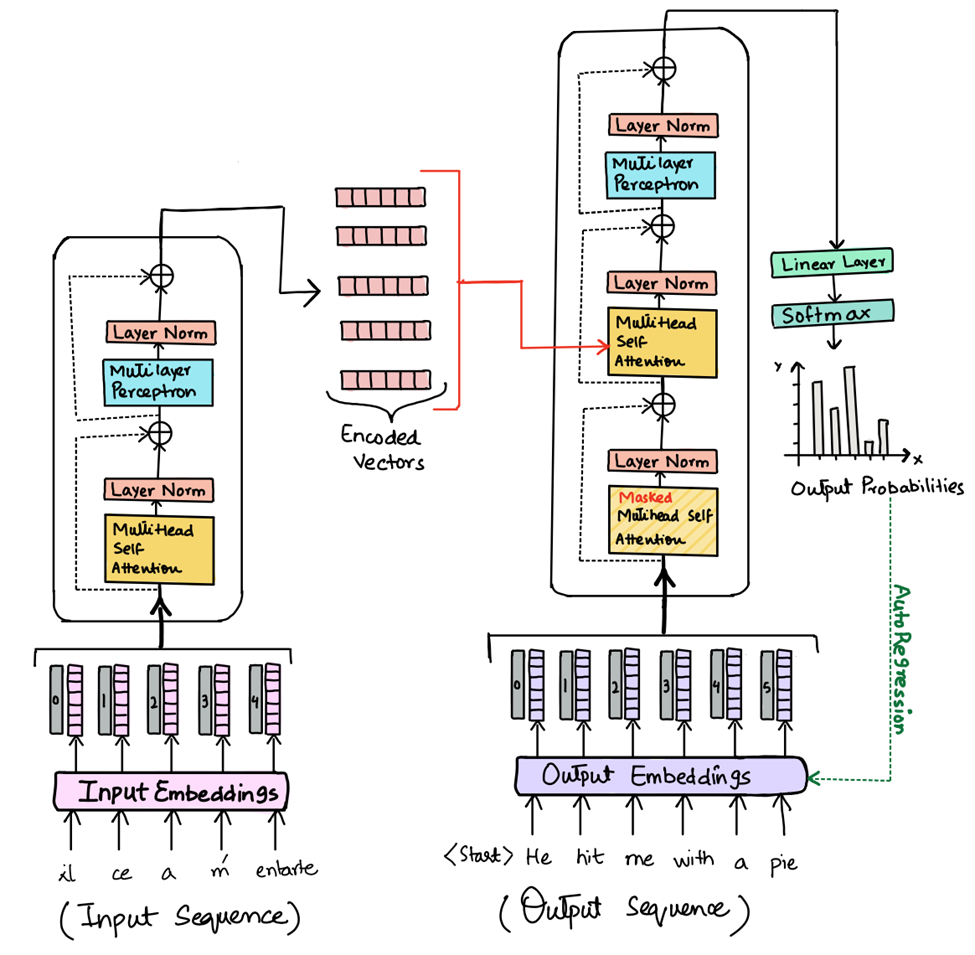


When an input sentence enters a Transformer, it is first tokenized into tokens and converted into token IDs. These IDs pass through the Embedding Layer, which maps each token to a dense vector representation. Since Transformers process tokens in parallel, Positional Encoding is added to the embeddings to inject information about the position of each token in the sequence.

The resulting embeddings are then passed to the Encoder Stack, which contains multiple Encoder Layers. In each encoder layer, the input first goes through Multi-Head Self-Attention. In this step, the model creates Query (Q), Key (K), and Value (V) vectors by multiplying the input embeddings with learned weight matrices. Then, it calculates attention scores using the scaled dot-product attention formula

This process allows each token in the sequence to attend to every other token, enabling the model to capture contextual relationships between words in the sentence.

The output from the Multi-Head Self-Attention layer is added to the original input using a Residual Connection, and then Layer Normalization is applied to make training more stable. The result is then passed to a Position-wise Feed-Forward Network (FFN), which has two linear layers with a non-linear activation such as ReLU or GELU. The Feed-Forward Network helps the model learn more complex patterns and improve the representation of each token. After this, another Residual Connection and Layer Normalization step is applied. This set of operations forms one encoder layer, and many such layers are stacked together in the encoder stack to produce richer and more contextual representations of the input tokens.

The encoder output is then passed to the Decoder Stack, which also contains several Decoder Layers. Each decoder layer begins with Masked Multi-Head Self-Attention, where future tokens are masked to ensure that the model only attends to previously generated tokens during sequence generation.

Next, the decoder performs Encoder–Decoder Attention (Cross Attention), where the decoder queries attend to the encoder outputs to incorporate relevant information from the input sequence. The result then passes through Add & Layer Normalization, followed by a Feed Forward Network, and another Add & Layer Normalization step.

Finally, the decoder output is projected through a Linear Layer, and a Softmax Layer converts the logits into a probability distribution over the vocabulary. The token with the highest probability is selected as the next token, and it is fed back into the decoder to generate the sequence autoregressively until an end token is produced.

## What is self-attention?

Self-attention is a mechanism in Transformers that allows each word (or token) in a sequence to focus on other words in the same sequence to understand context. It answers the question:

“Which words in this sentence are important to understanding this word?”

## How It Works

- Every token is represented as a vector.

- For each token, the model computes three vectors:

  - Query (Q) – what this token is looking for

  - Key (K) – what this token contains

  - Value (V) – the actual information of the token

- The attention score is calculated by comparing the query of one token with the keys of all tokens.

- These scores are normalized using softmax to produce weights.

- Each token’s final representation is the weighted sum of all token values, meaning it now contains information about the words it “attended to.”


## Scaled Dot-Product Attention

Scaled dot-product attention is the core computation of self-attention. It determines how much attention each token should give to other tokens in a sequence by comparing queries (Q) and keys (K) and applying it to the values (V).

1️⃣ How It Works

- Dot Product: Compute the dot product between the Query (Q) of a token and the Key (K) of every token in the sequence.

  - This measures similarity/importance between tokens.

- Scaling: Divide the dot product by √(dimension of K).

  - This prevents large values in the dot product that can make softmax outputs unstable.

- Softmax: Apply softmax to the scaled scores to get attention weights.

  - Weights determine how much each token should contribute to the current token’s new representation.

- Weighted Sum: Multiply the weights by the Value (V) vectors and sum them.

  - Produces a context-aware representation for the token.

2️⃣ Formula

The formula for scaled dot-product attention is:

$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$
Where:  
- **Q** = Query matrix  
- **K** = Key matrix  
- **V** = Value matrix  
- **d_k** = Dimension of the key vectors

This is the core computation of **self-attention** in Transformers.

3️⃣ Why Scaling is Important

- Without scaling, large dot-product values can cause softmax gradients to be very small, slowing down training.

- Dividing by √(dimension of K) keeps values in a stable range.


Scaled dot-product attention decides how much weight to give each participant when forming your own understanding

## Multi-Head Attention

Multi-head attention extends self-attention by allowing the model to focus on different aspects of the sequence simultaneously. Instead of using a single attention computation, it uses multiple “heads” in parallel.

1️⃣ How It Works

- Linear Projections: The input embeddings are linearly projected into multiple sets of queries (Q), keys (K), and values (V) — one set per head.

- Parallel Attention: Each head performs scaled dot-product attention independently.

- Concatenation: The outputs of all attention heads are concatenated.

- Final Linear Layer: The concatenated output is passed through a linear layer to produce the final multi-head attention representation.

4️⃣ Formula (Simplified)

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$
$$\text{where } \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

## Positional Encoding

Since Transformers process all tokens in parallel, they have no inherent sense of word order. Positional encoding is added to token embeddings to inject information about the position of each token in the sequence.

1️⃣ How It Works

Each token embedding is combined with a positional vector that encodes its position in the sequence.

The standard method uses sinusoidal functions:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

| Variable | Definition | Role in the Model |
| :--- | :--- | :--- |
| **$pos$** | **Token Position** | The index of the word (e.g., in "The cat sat," *The*=0, *cat*=1, *sat*=2). It represents the **row** in the encoding matrix. |
| **$i$** | **Dimension Index** | The specific feature index within the embedding (from $0$ to $d_{model}/2$). It determines the **wavelength** of the sine/cosine wave. |
| **$d_{model}$** | **Model Depth** | The total size of the vector representing a word (e.g., 512). This determines the **width** of the encoding vector. |


## Layer normalization 

Layer normalization (LayerNorm) is a technique used to stabilize and accelerate the training of deep neural networks. In Transformers, it ensures that the outputs of each layer have a consistent scale and distribution, making the model more stable and efficient.

1️⃣ How It Works

For each input vector to a layer, LayerNorm computes:

Mean (μ) of the vector

Variance (σ²) of the vector

Then it normalizes each element:

Normalized
=
𝑥
𝑖
−
𝜇
𝜎
2
+
𝜖
Normalized=
σ
2
+ϵ
	​

x
i
	​

−μ
	​


Optionally, learnable scaling (γ) and shifting (β) parameters are applied:

Output
=
𝛾
⋅
Normalized
+
𝛽
Output=γ⋅Normalized+β
2️⃣ Why It’s Important

⚡ Stabilizes Training: Keeps activations in a consistent range across layers.

🧠 Faster Convergence: Prevents gradient explosion or vanishing in deep stacks of layers.

🔄 Works Well with Residual Connections: Helps residual connections pass useful information without being distorted.

## Residual connections

Residual connections (or skip connections) are a technique in deep neural networks where the input of a layer is added directly to its output. In Transformers, they help the model retain information from earlier layers and stabilize training.

1️⃣ How It Works

Suppose a layer performs a transformation 
𝐹
(
𝑥
)
F(x) on input 
𝑥
x.

Instead of just passing 
𝐹
(
𝑥
)
F(x) to the next layer, the model outputs:

Output
=
𝐹
(
𝑥
)
+
𝑥
Output=F(x)+x

This “skips” the layer’s transformation and adds the original input back.

Often followed by Layer Normalization for stability.

2️⃣ Why It’s Important

🧠 Prevents Information Loss: Earlier layer features are preserved and carried forward.

⚡ Eases Training of Deep Networks: Helps gradients flow backward efficiently, avoiding vanishing/exploding gradients.

🔄 Works Well with LayerNorm and Attention: Ensures attention outputs don’t overwrite useful input information.

## Feed-forward networks

In Transformers, a Feed-Forward Network is a fully connected neural network applied independently to each token’s representation after attention. It helps the model transform and enrich the token embeddings.

1️⃣ How It Works

Each token embedding is passed through two linear layers with a ReLU activation in between:

FFN
(
𝑥
)
=
max
(
0
,
𝑥
𝑊
1
+
𝑏
1
)
𝑊
2
+
𝑏
2
FFN(x)=max(0,xW
1
	​

+b
1
	​

)W
2
	​

+b
2
	​


The first layer expands the dimension (adds capacity), and the second layer projects it back to the original embedding size.

FFNs are applied independently to each token, not across tokens.

2️⃣ Why It’s Important

🧠 Adds Non-Linearity: Allows the model to learn complex transformations beyond linear attention.

⚡ Enhances Representation: Each token embedding is enriched with additional features.

🔄 Independent for Tokens: Helps in parallel processing, keeping computation efficient.

## Why transformers scale well


Transformers have become the backbone of large language models and many NLP systems because their architecture is highly parallelizable, flexible, and efficient at capturing complex patterns.

1️⃣ Parallel Processing

Unlike RNNs, Transformers do not process sequences token by token.

All tokens are processed simultaneously, which allows massive parallelization on GPUs and TPUs.

⚡ Faster training means you can scale models to billions of parameters without prohibitive slowdowns.

2️⃣ Attention Mechanism

Self-attention captures relationships between all tokens regardless of distance.

No sequential bottleneck → long-range dependencies are learned efficiently.

Enables scaling to long sequences without loss of context.

3️⃣ Modular Architecture

Transformers are built from stacked layers of attention + feed-forward networks, which are identical and independent.

This modularity makes it easy to increase depth (more layers) or width (more hidden units) to scale model capacity.

4️⃣ Multi-Head Attention

Multiple attention heads allow the model to capture different aspects of sequences simultaneously.

Scaling the number of heads improves model expressivity without changing the fundamental architecture.

5️⃣ Efficient Memory and Computation

Matrix multiplications dominate computations → highly optimized on modern hardware.

With techniques like mixed-precision training, gradient checkpointing, and sparse attention, Transformers can scale to hundreds of billions of parameters.